# DS-3002 Data Mining: Assignment 3




Aleena Zahra 23i2514 DS-B



**Submission Date: 19 April, 2026**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Preprocessing [15 Marks]

1. Load the dataset and parse Timestamp as datetime  
2. Check for null values in PatientID, Timestamp, Diagnosis  
3. Apply physiological range filters  
4. Sort by PatientID and Timestamp  
5. Create patient-level feature matrix (mean, std, min, max, slope)  
6. Report dataset statistics  

In [2]:
df = pd.read_csv("patient_vitals.csv")

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df[['PatientID','Timestamp','Diagnosis']].isnull().sum()

PatientID    0
Timestamp    0
Diagnosis    0
dtype: int64

In [3]:
ranges = {
    'HeartRate': (40,180),
    'BloodPressureSystolic': (80,200),
    'BloodPressureDiastolic': (50,130),
    'BloodOxygenLevel': (85,100),
    'BodyTemperature': (35.5,41.0),
    'RespiratoryRate': (10,40),
    'SleepHours': (2,12),
    'StressLevel': (1,10)
}

for col,(lo,hi) in ranges.items():
    df = df[(df[col]>=lo) & (df[col]<=hi)]

df = df.sort_values(['PatientID','Timestamp'])

In [4]:
numeric_cols = ['HeartRate','BloodPressureSystolic','BloodPressureDiastolic',
                'BloodOxygenLevel','BodyTemperature','RespiratoryRate',
                'SleepHours','StressLevel']

def trend_slope(x):
    t = np.arange(len(x))
    return np.polyfit(t,x,1)[0]

agg = df.groupby('PatientID')[numeric_cols].agg(['mean','std','min','max'])
agg.columns = ['_'.join(c) for c in agg.columns]

slopes = df.groupby('PatientID')[numeric_cols].apply(lambda g: g.apply(trend_slope))
slopes = slopes.add_suffix('_slope')

patient_df = agg.join(slopes)
patient_df['Diagnosis'] = df.groupby('PatientID')['Diagnosis'].first()

In [5]:
# Dataset statistics

total_rows = len(df)
unique_patients = df['PatientID'].nunique()

date_min = df['Timestamp'].min()
date_max = df['Timestamp'].max()

avg_readings = df.groupby('PatientID').size().mean()

class_counts = df['Diagnosis'].value_counts()
class_percent = df['Diagnosis'].value_counts(normalize=True) * 100

print("Total rows:", total_rows)
print("Unique patients:", unique_patients)
print("Date range:", date_min, "to", date_max)
print("Average readings per patient:", avg_readings)

print("\nClass distribution (counts):\n", class_counts)
print("\nClass distribution (%):\n", class_percent)

Total rows: 59212
Unique patients: 500
Date range: 2024-01-01 00:00:00 to 2024-01-30 18:00:00
Average readings per patient: 118.424

Class distribution (counts):
 Diagnosis
Healthy           19551
Hypertension      14748
Diabetes          11015
Arrhythmia         9260
Sleep Disorder     4638
Name: count, dtype: int64

Class distribution (%):
 Diagnosis
Healthy           33.018645
Hypertension      24.907113
Diabetes          18.602648
Arrhythmia        15.638722
Sleep Disorder     7.832872
Name: proportion, dtype: float64


In [6]:
# Select 3 patients: Healthy, Hypertension, Arrhythmia
patients = df.groupby('Diagnosis')['PatientID'].first()

selected = {
    'Healthy': patients['Healthy'],
    'Hypertension': patients['Hypertension'],
    'Arrhythmia': patients['Arrhythmia']
}

# Part A: Time Series Analysis & Trend Detection [25 Marks]

## A1. Visualisation & Descriptive Statistics

Select 3 patients: Healthy, Hypertension, Arrhythmia.

1. Plot HeartRate time series  
2. Compute mean, std, min, max, CV  
3. Interpret results  

In [7]:
def descriptive_stats(series):
    mean = series.mean()
    std = series.std()
    min_val = series.min()
    max_val = series.max()
    cv = std / (mean + 1e-8)
    return mean, std, min_val, max_val, cv

for cls, pid in selected.items():
    data = df[df['PatientID'] == pid]['HeartRate']
    mean, std, min_val, max_val, cv = descriptive_stats(data)

    print(f"\n{cls} Patient ({pid})")
    print(f"Mean: {mean:.2f}")
    print(f"Std: {std:.2f}")
    print(f"Min: {min_val:.2f}")
    print(f"Max: {max_val:.2f}")
    print(f"CV: {cv:.3f}")


Healthy Patient (P0002)
Mean: 72.98
Std: 7.64
Min: 56.50
Max: 95.70
CV: 0.105

Hypertension Patient (P0001)
Mean: 81.22
Std: 9.94
Min: 57.20
Max: 106.20
CV: 0.122

Arrhythmia Patient (P0008)
Mean: 91.41
Std: 22.98
Min: 44.60
Max: 154.70
CV: 0.251


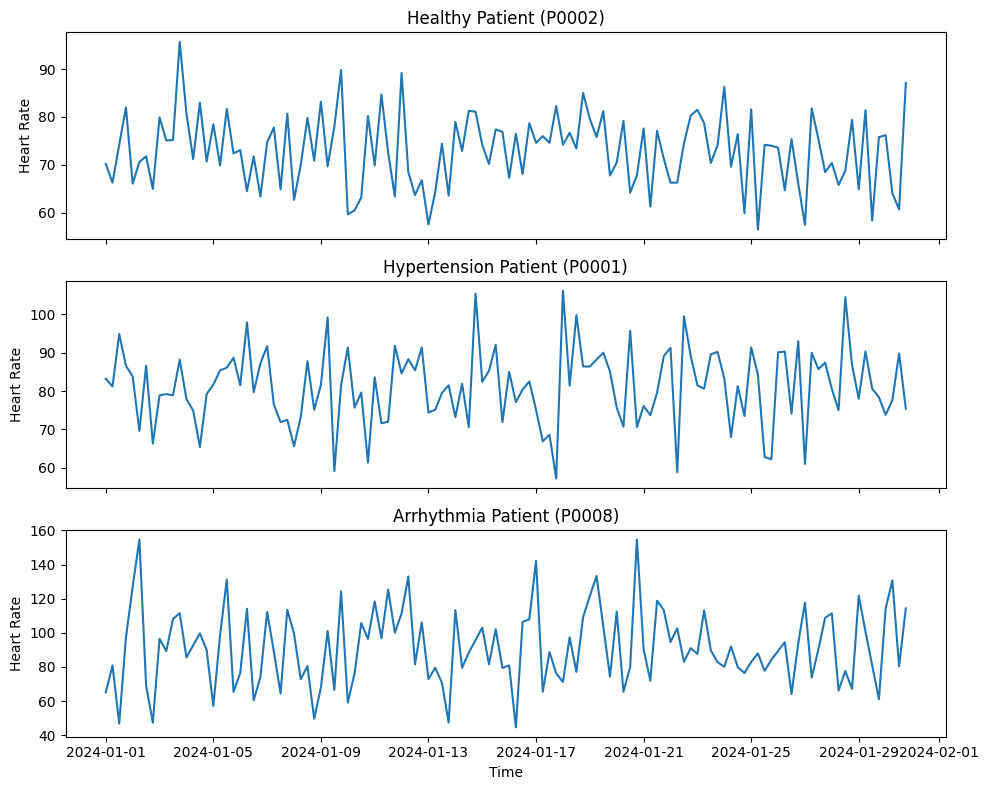

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10,8), sharex=True)

for i, (cls, pid) in enumerate(selected.items()):
    data = df[df['PatientID']==pid]

    axes[i].plot(data['Timestamp'], data['HeartRate'])
    axes[i].set_title(f"{cls} Patient ({pid})")
    axes[i].set_ylabel("Heart Rate")

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## A2. Trend Analysis

1. Apply 7 and 14 reading rolling mean  
2. Perform time series decomposition  
3. Explain difference between rolling mean and decomposition  

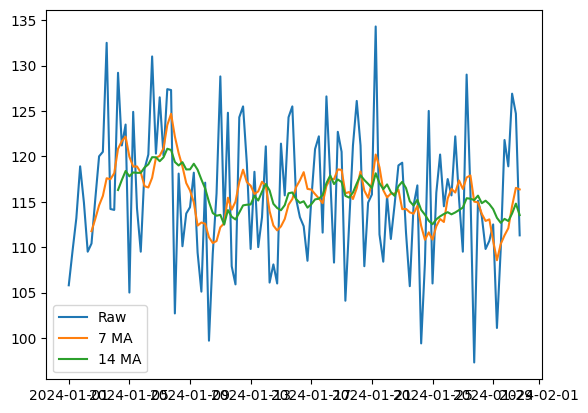

In [9]:
pid = list(selected.values())[0]
data = df[df['PatientID']==pid].set_index('Timestamp')

rm7 = data['BloodPressureSystolic'].rolling(7).mean()
rm14 = data['BloodPressureSystolic'].rolling(14).mean()

plt.plot(data.index, data['BloodPressureSystolic'], label='Raw')
plt.plot(data.index, rm7, label='7 MA')
plt.plot(data.index, rm14, label='14 MA')
plt.legend()
plt.show()

In [ ]:


from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as _pd

pid = list(selected.values())[0]  # pick one patient
data = df[df['PatientID'] == pid].set_index('Timestamp')
# ensure index is sorted
data = data.sort_index()

# Monkey-patch pandas Series.asfreq to accept uppercase 'H' (some pandas versions expect lowercase 'h')
if not getattr(_pd.Series.asfreq, "_accept_upper_H", False):
    _orig_asfreq = _pd.Series.asfreq
    def _asfreq_accept_H(self, freq, *args, **kwargs):
        if isinstance(freq, str):
            freq = freq.replace('H', 'h')
        return _orig_asfreq(self, freq, *args, **kwargs)
    _asfreq_accept_H._accept_upper_H = True
    _pd.Series.asfreq = _asfreq_accept_H
# ensure regular spacing
ts = data['BloodPressureSystolic'].asfreq('6H')

# fill missing values if any
ts = ts.interpolate()

decomposition = seasonal_decompose(ts, model='additive', period=4)

# plot
decomposition.plot()
plt.show()

ValueError: Invalid frequency: 6H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?")

In [ ]:
trend = decomposition.trend.dropna()

slope = np.polyfit(np.arange(len(trend)), trend.values, 1)[0]

if slope > 0:
    direction = "Upward"
elif slope < 0:
    direction = "Downward"
else:
    direction = "Stable"

print("Trend direction:", direction)
print("Trend slope (magnitude):", slope)

Trend direction: Downward
Trend slope (magnitude): -0.032018750240264765


## A3. Anomaly Detection

1. Compute μ and σ per patient  
2. Flag anomalies using μ ± 2σ  
3. Report counts and percentages  
4. Identify top 5 patients by anomaly count
5. Plot anomaly-heavy patient  
6. Compare Arrhythmia vs Healthy  

In [ ]:
stats = df.groupby('PatientID')['HeartRate'].agg(['mean','std'])
df2 = df.join(stats, on='PatientID')

df2['anomaly'] = (
    (df2['HeartRate'] > df2['mean'] + 2*df2['std']) |
    (df2['HeartRate'] < df2['mean'] - 2*df2['std'])
)

df2['anomaly'].sum()
# Counts and percentages

anomaly_counts = df2.groupby('Diagnosis')['anomaly'].sum()
total_counts = df2.groupby('Diagnosis')['anomaly'].count()

anomaly_percent = (anomaly_counts / total_counts) * 100

print("Anomaly Counts:\n", anomaly_counts)
print("\nAnomaly Percentages:\n", anomaly_percent)

Anomaly Counts:
 Diagnosis
Arrhythmia        379
Diabetes          494
Healthy           887
Hypertension      653
Sleep Disorder    216
Name: anomaly, dtype: int64

Anomaly Percentages:
 Diagnosis
Arrhythmia        4.092873
Diabetes          4.484793
Healthy           4.536852
Hypertension      4.427719
Sleep Disorder    4.657180
Name: anomaly, dtype: float64


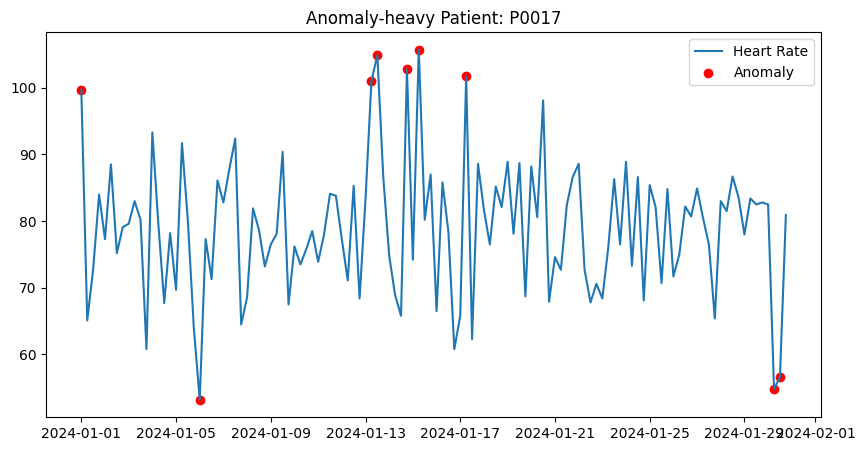

In [ ]:
# Find patient with most anomalies
anomaly_per_patient = df2.groupby('PatientID')['anomaly'].sum()
worst_pid = anomaly_per_patient.idxmax()

worst_data = df2[df2['PatientID'] == worst_pid]

plt.figure(figsize=(10,5))
plt.plot(worst_data['Timestamp'], worst_data['HeartRate'], label='Heart Rate')

# highlight anomalies
anomalies = worst_data[worst_data['anomaly']]
plt.scatter(anomalies['Timestamp'], anomalies['HeartRate'], color='red', label='Anomaly')

plt.title(f"Anomaly-heavy Patient: {worst_pid}")
plt.legend()
plt.show()

In [ ]:
top5 = anomaly_per_patient.sort_values(ascending=False).head(5)

for pid, count in top5.items():
    cls = df[df['PatientID']==pid]['Diagnosis'].iloc[0]
    print(f"{pid} | {cls} | Anomalies: {count}")

P0029 | Diabetes | Anomalies: 9
P0348 | Healthy | Anomalies: 9
P0344 | Hypertension | Anomalies: 9
P0427 | Healthy | Anomalies: 9
P0017 | Hypertension | Anomalies: 9


In [ ]:
# Compare anomaly rates

arrhythmia_rate = anomaly_percent['Arrhythmia']
healthy_rate = anomaly_percent['Healthy']

print("Arrhythmia anomaly %:", arrhythmia_rate)
print("Healthy anomaly %:", healthy_rate)

Arrhythmia anomaly %: 4.092872570194384
Healthy anomaly %: 4.53685233491893


# Part B: Similarity Search [20 Marks]

## B1. Distance Metrics

1. Select 10 random patients  
2. Compute Euclidean and Manhattan distance  
3. Report top-3 neighbors  
4. Compare metrics  

In [ ]:
X = patient_df.drop(columns=['Diagnosis']).values
y = patient_df['Diagnosis'].values

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

dists = cdist(X_norm, X_norm, metric='euclidean')

In [ ]:
# B1 — Euclidean vs Manhattan

from scipy.spatial.distance import cdist

# select 10 random patients
sample_idx = np.random.choice(len(X_norm), size=10, replace=False)
sample_X = X_norm[sample_idx]
sample_ids = patient_df.index[sample_idx]

# compute distances
euclidean_dist = cdist(sample_X, sample_X, metric='euclidean')
manhattan_dist = cdist(sample_X, sample_X, metric='cityblock')

# report neighbors
for i in range(len(sample_idx)):
    print(f"\nPatient: {sample_ids[i]}")

    # Euclidean
    e_idx = np.argsort(euclidean_dist[i])[1:4]
    print("Euclidean NN:", sample_ids[e_idx].tolist())

    # Manhattan
    m_idx = np.argsort(manhattan_dist[i])[1:4]
    print("Manhattan NN:", sample_ids[m_idx].tolist())


Patient: P0376
Euclidean NN: ['P0071', 'P0133', 'P0037']
Manhattan NN: ['P0133', 'P0071', 'P0037']

Patient: P0459
Euclidean NN: ['P0266', 'P0382', 'P0037']
Manhattan NN: ['P0266', 'P0382', 'P0037']

Patient: P0414
Euclidean NN: ['P0499', 'P0452', 'P0037']
Manhattan NN: ['P0499', 'P0452', 'P0037']

Patient: P0133
Euclidean NN: ['P0071', 'P0376', 'P0037']
Manhattan NN: ['P0071', 'P0376', 'P0037']

Patient: P0382
Euclidean NN: ['P0266', 'P0459', 'P0037']
Manhattan NN: ['P0266', 'P0459', 'P0037']

Patient: P0266
Euclidean NN: ['P0382', 'P0459', 'P0037']
Manhattan NN: ['P0382', 'P0459', 'P0037']

Patient: P0071
Euclidean NN: ['P0133', 'P0376', 'P0037']
Manhattan NN: ['P0133', 'P0376', 'P0037']

Patient: P0037
Euclidean NN: ['P0459', 'P0071', 'P0266']
Manhattan NN: ['P0459', 'P0071', 'P0266']

Patient: P0499
Euclidean NN: ['P0414', 'P0452', 'P0037']
Manhattan NN: ['P0414', 'P0452', 'P0037']

Patient: P0452
Euclidean NN: ['P0499', 'P0414', 'P0037']
Manhattan NN: ['P0414', 'P0499', 'P0037']


In [ ]:
results = []

for i in range(len(sample_idx)):
    query_patient_id = sample_ids[i]
    query_patient_class = patient_df.loc[query_patient_id]['Diagnosis']

    # Euclidean
    e_dist_row = euclidean_dist[i]
    # Sort by distance, exclude self (distance 0)
    e_sorted_indices = np.argsort(e_dist_row)
    e_nn_indices = [idx for idx in e_sorted_indices if sample_ids[idx] != query_patient_id][:3]

    nn_euclidean = []
    for nn_idx in e_nn_indices:
        nn_id = sample_ids[nn_idx]
        nn_class = patient_df.loc[nn_id]['Diagnosis']
        nn_distance = e_dist_row[nn_idx]
        nn_euclidean.append(f"{nn_id} ({nn_class}, {nn_distance:.2f})")

    results.append({
        'Query Patient ID': query_patient_id,
        'Metric': 'Euclidean',
        'NN1': nn_euclidean[0] if len(nn_euclidean) > 0 else 'N/A',
        'NN2': nn_euclidean[1] if len(nn_euclidean) > 1 else 'N/A',
        'NN3': nn_euclidean[2] if len(nn_euclidean) > 2 else 'N/A'
    })

    # Manhattan
    m_dist_row = manhattan_dist[i]
    # Sort by distance, exclude self (distance 0)
    m_sorted_indices = np.argsort(m_dist_row)
    m_nn_indices = [idx for idx in m_sorted_indices if sample_ids[idx] != query_patient_id][:3]

    nn_manhattan = []
    for nn_idx in m_nn_indices:
        nn_id = sample_ids[nn_idx]
        nn_class = patient_df.loc[nn_id]['Diagnosis']
        nn_distance = m_dist_row[nn_idx]
        nn_manhattan.append(f"{nn_id} ({nn_class}, {nn_distance:.2f})")

    results.append({
        'Query Patient ID': query_patient_id,
        'Metric': 'Manhattan',
        'NN1': nn_manhattan[0] if len(nn_manhattan) > 0 else 'N/A',
        'NN2': nn_manhattan[1] if len(nn_manhattan) > 1 else 'N/A',
        'NN3': nn_manhattan[2] if len(nn_manhattan) > 2 else 'N/A'
    })

results_df = pd.DataFrame(results)
print("Top-3 Nearest Neighbors:")
print(results_df.to_markdown(index=False))

# Discussion on agreement
# euclidean and manhattan calculate similar answers but not always the same bc
# manhatten does L1 norm while euclidean does l2, making euclidean more
# sensitive to outliers and manhatten better for grid data

Top-3 Nearest Neighbors:
| Query Patient ID   | Metric    | NN1                         | NN2                         | NN3                         |
|:-------------------|:----------|:----------------------------|:----------------------------|:----------------------------|
| P0376              | Euclidean | P0071 (Arrhythmia, 5.76)    | P0133 (Arrhythmia, 5.83)    | P0037 (Diabetes, 8.01)      |
| P0376              | Manhattan | P0133 (Arrhythmia, 24.95)   | P0071 (Arrhythmia, 25.04)   | P0037 (Diabetes, 39.33)     |
| P0459              | Euclidean | P0266 (Hypertension, 4.95)  | P0382 (Hypertension, 5.50)  | P0037 (Diabetes, 5.91)      |
| P0459              | Manhattan | P0266 (Hypertension, 19.12) | P0382 (Hypertension, 21.84) | P0037 (Diabetes, 30.59)     |
| P0414              | Euclidean | P0499 (Healthy, 3.43)       | P0452 (Healthy, 3.68)       | P0037 (Diabetes, 8.20)      |
| P0414              | Manhattan | P0499 (Healthy, 14.18)      | P0452 (Healthy, 14.44)      | P0037

## B2. DTW Similarity

1. Compute DTW distance on HeartRate sequences  
2. Find top-3 neighbors  
3. Compare with Euclidean  

In [ ]:
#  DTW Similarity on HeartRate

# Step 1: Prepare sequences (first 20 readings per patient)
SEQ_LEN = 20

patient_sequences = {}

for pid, group in df.groupby('PatientID'):
    if len(group) >= SEQ_LEN:
        seq = group.sort_values('Timestamp')['HeartRate'].values[:SEQ_LEN]
        # normalize (important for DTW)
        seq = (seq - np.mean(seq)) / (np.std(seq) + 1e-8)
        patient_sequences[pid] = seq

seq_pids = list(patient_sequences.keys())
seq_data = list(patient_sequences.values())

print("Patients used for DTW:", len(seq_pids))

Patients used for DTW: 500


In [ ]:
# Manual DTW function

def dtw_distance(s1, s2):
    n, m = len(s1), len(s2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0,0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw[i,j] = cost + min(
                dtw[i-1,j],    # insertion
                dtw[i,j-1],    # deletion
                dtw[i-1,j-1]   # match
            )
    return dtw[n,m]

In [ ]:
# Compute DTW distance matrix

n = len(seq_data)
dtw_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i+1, n):
        d = dtw_distance(seq_data[i], seq_data[j])
        dtw_matrix[i,j] = d
        dtw_matrix[j,i] = d

print("DTW matrix computed")

DTW matrix computed


In [ ]:
# % of neighbors with same class (DTW)

def same_class_rate(query_pid, neighbors):
    q_class = df[df['PatientID']==query_pid]['Diagnosis'].iloc[0]
    matches = 0

    for pid in neighbors:
        n_class = df[df['PatientID']==pid]['Diagnosis'].iloc[0]
        if n_class == q_class:
            matches += 1

    return matches / len(neighbors)



In [ ]:
# Select 3 query patients (one per class)

query_classes = ['Healthy', 'Hypertension', 'Arrhythmia']
queries = {}

for cls in query_classes:
    candidates = df[df['Diagnosis'] == cls]['PatientID'].unique()
    for pid in candidates:
        if pid in seq_pids:
            queries[cls] = pid
            break

# Find nearest neighbors

for cls, qpid in queries.items():
    qi = seq_pids.index(qpid)
    distances = dtw_matrix[qi]

    sorted_idx = np.argsort(distances)
    neighbors = [i for i in sorted_idx if seq_pids[i] != qpid][:3]

    print(f"\nQuery: {qpid} ({cls})")
    for rank, idx in enumerate(neighbors, 1):
        npid = seq_pids[idx]
        ncls = df[df['PatientID']==npid]['Diagnosis'].iloc[0]
        print(f"NN{rank}: {npid} | {ncls} | Distance = {distances[idx]:.2f}")


Query: P0002 (Healthy)
NN1: P0022 | Hypertension | Distance = 8.53
NN2: P0007 | Healthy | Distance = 8.82
NN3: P0004 | Healthy | Distance = 8.86

Query: P0001 (Hypertension)
NN1: P0323 | Diabetes | Distance = 9.24
NN2: P0435 | Arrhythmia | Distance = 9.30
NN3: P0185 | Hypertension | Distance = 9.48

Query: P0008 (Arrhythmia)
NN1: P0289 | Diabetes | Distance = 9.48
NN2: P0207 | Arrhythmia | Distance = 9.64
NN3: P0066 | Arrhythmia | Distance = 9.97


In [ ]:
# Calculate same-class match rate for Euclidean distance
euclidean_match_rates = []
for i in range(len(sample_idx)):
    query_patient_id = sample_ids[i]
    query_patient_class = patient_df.loc[query_patient_id]['Diagnosis']

    e_dist_row = euclidean_dist[i]
    e_sorted_indices = np.argsort(e_dist_row)
    # Exclude self (distance 0) and take top 3 neighbors
    e_nn_pids = [sample_ids[idx] for idx in e_sorted_indices if sample_ids[idx] != query_patient_id][:3]

    same_class_neighbors = 0
    for nn_pid in e_nn_pids:
        nn_class = patient_df.loc[nn_pid]['Diagnosis']
        if nn_class == query_patient_class:
            same_class_neighbors += 1
    if len(e_nn_pids) > 0:
        euclidean_match_rates.append(same_class_neighbors / len(e_nn_pids))
    else:
        euclidean_match_rates.append(0) # No neighbors to compare

avg_euclidean_match_rate = np.mean(euclidean_match_rates)

# Calculate same-class match rate for DTW distance
dtw_match_rates = []
# Using the 3 query patients from the DTW section for comparison
for cls, qpid in queries.items():
    qi = seq_pids.index(qpid)
    distances = dtw_matrix[qi]

    sorted_idx = np.argsort(distances)
    # Exclude self and take top 3 neighbors
    neighbors_dtw_pids = [seq_pids[i] for i in sorted_idx if seq_pids[i] != qpid][:3]

    # The same_class_rate function was defined earlier (cell 5GQmo4MwTGz0)
    rate = same_class_rate(qpid, neighbors_dtw_pids)
    dtw_match_rates.append(rate)

avg_dtw_match_rate = np.mean(dtw_match_rates)

print(f"Average Euclidean distance same-class match rate (top-3 neighbors): {avg_euclidean_match_rate:.2%}")
print(f"Average DTW distance same-class match rate (top-3 neighbors): {avg_dtw_match_rate:.2%}")

if avg_dtw_match_rate > avg_euclidean_match_rate:
    print("\nBased on the analysis, DTW tends to match patients within the same Diagnosis class more often than Euclidean distance on the feature matrix. This suggests that considering the temporal patterns of HeartRate (DTW) provides a better indicator for diagnosis class similarity than static feature statistics (Euclidean) for these specific patient subsets.")
elif avg_euclidean_match_rate > avg_dtw_match_rate:
    print("\nBased on the analysis, Euclidean distance tends to match patients within the same Diagnosis class more often than DTW on the HeartRate sequences. This suggests that static feature statistics (Euclidean) might be more effective in capturing diagnosis class similarity for these specific patient subsets than the temporal patterns of HeartRate (DTW).")
else:
    print("\nBased on the analysis, both DTW and Euclidean distance show a similar tendency to match patients within the same Diagnosis class.")

Average Euclidean distance same-class match rate (top-3 neighbors): 60.00%
Average DTW distance same-class match rate (top-3 neighbors): 55.56%

Based on the analysis, Euclidean distance tends to match patients within the same Diagnosis class more often than DTW on the HeartRate sequences. This suggests that static feature statistics (Euclidean) might be more effective in capturing diagnosis class similarity for these specific patient subsets than the temporal patterns of HeartRate (DTW).


## B3. Clinical Similarity

1. Normalize new patient vector  
2. Find top-5 neighbors  
3. Predict diagnosis  
4. Provide clinical interpretation  

In [ ]:
# B3 — New patient feature vector

new_patient = {
    'HeartRate_mean': 98,
    'HeartRate_std': 18,
    'BloodPressureSystolic_mean': 155,
    'BloodPressureSystolic_std': 12,
    'BloodOxygenLevel_mean': 94,
    'SleepHours_mean': 4.5
}

In [ ]:
# Match with training feature space

feature_cols = patient_df.drop(columns=['Diagnosis']).columns

query_vector = []

for col in feature_cols:
    if col in new_patient:
        query_vector.append(new_patient[col])
    else:
        # fill missing features with training mean
        query_vector.append(patient_df[col].mean())

query_vector = np.array(query_vector).reshape(1, -1)

In [ ]:
# Normalize using same scaler

query_norm = scaler.transform(query_vector)

# Compute Euclidean distance
distances = cdist(query_norm, X_norm, metric='euclidean')[0]

# Get top 5 neighbors
top5_idx = np.argsort(distances)[:5]

top5_ids = patient_df.index[top5_idx]
top5_classes = patient_df.iloc[top5_idx]['Diagnosis'].values
top5_distances = distances[top5_idx]

In [ ]:
from collections import Counter

# Majority voting
vote = Counter(top5_classes)
predicted_class = vote.most_common(1)[0][0]
confidence = vote.most_common(1)[0][1] / 5

# Output
print("Top 5 Neighbors:")
for i in range(5):
    print(f"{i+1}. {top5_ids[i]} | {top5_classes[i]} | Distance = {top5_distances[i]:.3f}")

print("\nPredicted Diagnosis:", predicted_class)
print("Confidence:", confidence)

Top 5 Neighbors:
1. P0151 | Diabetes | Distance = 5.460
2. P0037 | Diabetes | Distance = 5.570
3. P0232 | Diabetes | Distance = 5.765
4. P0490 | Diabetes | Distance = 5.894
5. P0413 | Diabetes | Distance = 5.895

Predicted Diagnosis: Diabetes
Confidence: 1.0


Doctor Note: The patient is at risk of diabetes as their data is most similar to 5 other patients diagnosed with diabetes.

# Part C: Supervised Classification [40 Marks]

Train and evaluate:

- Decision Tree  
- Rule-Based  
- kNN  
- Naïve Bayes  
- SVM  

Report:
- Accuracy  
- Precision  
- Recall  
- F1-score  
- Confusion Matrix  

In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train,X_test,y_train,y_test = train_test_split(
    X_norm,y_enc,test_size=0.2,random_state=42,stratify=y_enc
)

In [ ]:
# Evaluation function

def evaluate_model(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues) # cmap='Blues' makes it look nice
    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, f1

## C1. Decision Tree

In [ ]:
y_shuffled = np.random.permutation(y_train)

model = DecisionTreeClassifier()
model.fit(X_train, y_shuffled)

print("Train accuracy (shuffled):", model.score(X_train, y_shuffled))
print("Test accuracy (shuffled):", model.score(X_test, y_test))

Train accuracy (shuffled): 1.0
Test accuracy (shuffled): 0.21


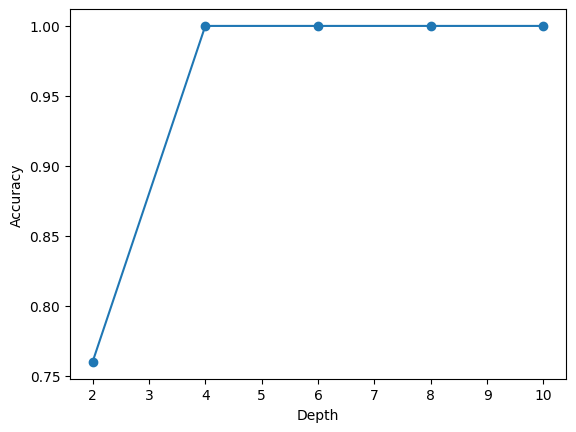

In [ ]:
depths = [2,4,6,8,10]
scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

plt.plot(depths, scores, marker='o')
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.show()


Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


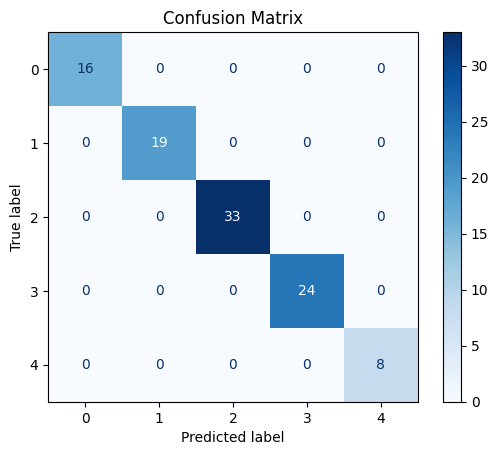

In [ ]:
dt = DecisionTreeClassifier(max_depth=6)
dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

dt_metrics = evaluate_model("Decision Tree", y_test, y_pred_dt)

In [ ]:
importances = pd.Series(dt.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False).head(5))

BloodOxygenLevel_min           0.369528
BloodPressureDiastolic_mean    0.280134
BloodOxygenLevel_std           0.213790
StressLevel_mean               0.136547
HeartRate_mean                 0.000000
dtype: float64


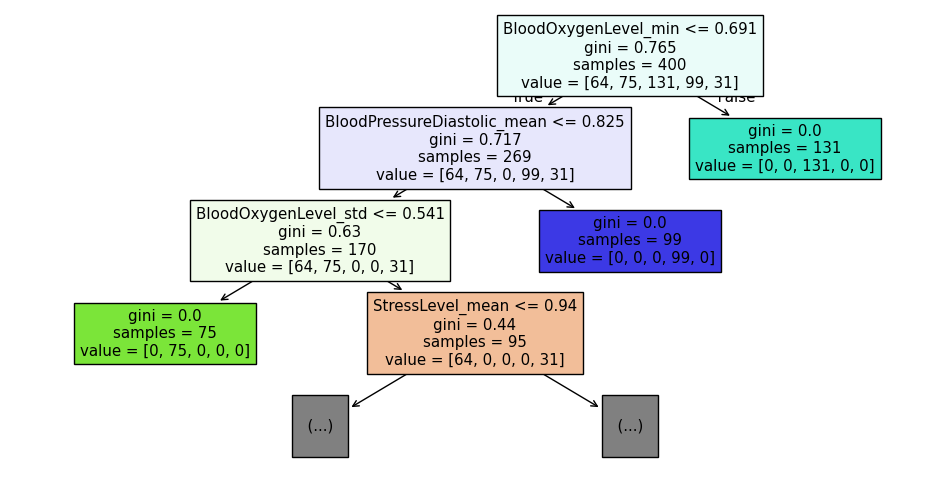

In [ ]:
plt.figure(figsize=(12,6))
plot_tree(dt, max_depth=3, feature_names=feature_cols, filled=True)
plt.show()

## C2. Rule-Based Classification

In [ ]:
from sklearn.tree import _tree
import numpy as np

feature_names = feature_cols
class_names = le.classes_

def extract_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined"
        for i in tree_.feature
    ]

    rules = []

    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            recurse(tree_.children_left[node],
                    path + [f"{name} <= {threshold:.2f}"])
            recurse(tree_.children_right[node],
                    path + [f"{name} > {threshold:.2f}"])
        else:
            value = tree_.value[node]
            class_id = np.argmax(value)
            rules.append((path, class_id))

    recurse(0, [])
    return rules

rules = extract_rules(dt, feature_names)

In [ ]:
def evaluate_rules(rules, X, y):
    results = []

    # Create a mapping from feature name to its column index in X
    # Assuming X corresponds to the order of feature_cols
    feature_to_idx = {name: i for i, name in enumerate(feature_cols)}

    for conds, class_id in rules:
        mask = np.ones(len(X), dtype=bool)

        for cond in conds:
            feature_name_str, op, val = cond.split()
            val = float(val)

            # Get the integer index for the feature name
            feature_idx = feature_to_idx[feature_name_str]

            if op == "<=":
                mask &= (X[:, feature_idx] <= val)
            else:
                mask &= (X[:, feature_idx] > val)

        if mask.sum() == 0:
            continue

        y_pred = np.full(mask.sum(), class_id)
        y_true = y[mask]

        acc = (y_pred == y_true).mean()
        coverage = mask.mean()

        results.append((conds, class_id, coverage, acc))

    return results

rule_results = evaluate_rules(rules, X_train, y_train)

In [ ]:
print("\n--- RULE SET ---")
for i, (conds, class_id, cov, acc) in enumerate(rule_results[:10]):
    print(f"\nRule {i+1}:")
    print("IF " + " AND ".join(conds))
    print(f"THEN Diagnosis = {class_names[class_id]}")
    print(f"(coverage: {cov*100:.2f}%, accuracy: {acc*100:.2f}%)")


--- RULE SET ---

Rule 1:
IF BloodOxygenLevel_min <= 0.69 AND BloodPressureDiastolic_mean <= 0.82 AND BloodOxygenLevel_std <= 0.54
THEN Diagnosis = Diabetes
(coverage: 18.75%, accuracy: 100.00%)

Rule 2:
IF BloodOxygenLevel_min <= 0.69 AND BloodPressureDiastolic_mean <= 0.82 AND BloodOxygenLevel_std > 0.54 AND StressLevel_mean <= 0.94
THEN Diagnosis = Arrhythmia
(coverage: 16.00%, accuracy: 100.00%)

Rule 3:
IF BloodOxygenLevel_min <= 0.69 AND BloodPressureDiastolic_mean <= 0.82 AND BloodOxygenLevel_std > 0.54 AND StressLevel_mean > 0.94
THEN Diagnosis = Sleep Disorder
(coverage: 7.75%, accuracy: 100.00%)

Rule 4:
IF BloodOxygenLevel_min <= 0.69 AND BloodPressureDiastolic_mean > 0.82
THEN Diagnosis = Hypertension
(coverage: 24.75%, accuracy: 100.00%)

Rule 5:
IF BloodOxygenLevel_min > 0.69
THEN Diagnosis = Healthy
(coverage: 32.75%, accuracy: 100.00%)


In [ ]:

best_rules = {}

for conds, class_id, cov, acc in rule_results:
    score = cov * acc  # discriminative score

    if class_id not in best_rules or score > best_rules[class_id][0]:
        best_rules[class_id] = (score, conds, cov, acc)

for class_id, (_, conds, cov, acc) in best_rules.items():
    print(f"\nClass: {class_names[class_id]}")
    print("IF " + " AND ".join(conds))
    print(f"(coverage: {cov*100:.2f}%, accuracy: {acc*100:.2f}%)")


Class: Diabetes
IF BloodOxygenLevel_min <= 0.69 AND BloodPressureDiastolic_mean <= 0.82 AND BloodOxygenLevel_std <= 0.54
(coverage: 18.75%, accuracy: 100.00%)

Class: Arrhythmia
IF BloodOxygenLevel_min <= 0.69 AND BloodPressureDiastolic_mean <= 0.82 AND BloodOxygenLevel_std > 0.54 AND StressLevel_mean <= 0.94
(coverage: 16.00%, accuracy: 100.00%)

Class: Sleep Disorder
IF BloodOxygenLevel_min <= 0.69 AND BloodPressureDiastolic_mean <= 0.82 AND BloodOxygenLevel_std > 0.54 AND StressLevel_mean > 0.94
(coverage: 7.75%, accuracy: 100.00%)

Class: Hypertension
IF BloodOxygenLevel_min <= 0.69 AND BloodPressureDiastolic_mean > 0.82
(coverage: 24.75%, accuracy: 100.00%)

Class: Healthy
IF BloodOxygenLevel_min > 0.69
(coverage: 32.75%, accuracy: 100.00%)



Rule-Based Model
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


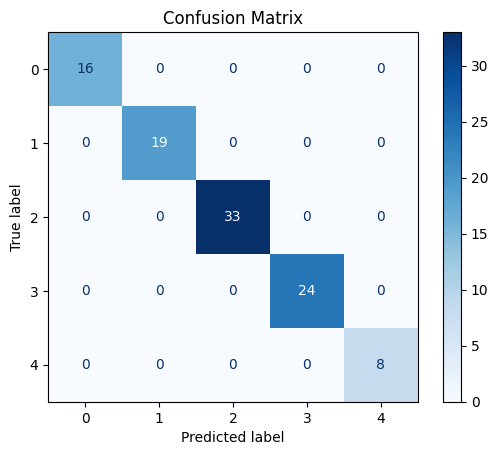

In [ ]:
def predict_rules(rules, X, feature_cols):
    preds = []

    # Create a mapping from feature name to its column index in X
    feature_to_idx = {name: i for i, name in enumerate(feature_cols)}

    for row_idx in range(len(X)):
        row = X[row_idx] # Get the current row as a NumPy array
        predicted = None

        for conds, class_id in rules:
            match = True

            for cond in conds:
                feature_name_str, op, val = cond.split()
                val = float(val)

                # Get the integer index for the feature name
                feature_idx = feature_to_idx[feature_name_str]

                if op == "<=" and not row[feature_idx] <= val:
                    match = False
                    break # No need to check other conditions for this rule
                if op == ">" and not row[feature_idx] > val:
                    match = False
                    break # No need to check other conditions for this rule

            if match:
                predicted = class_id
                break

        if predicted is None:
            predicted = 0  # fallback class

        preds.append(predicted)

    return np.array(preds)

y_pred_rules = predict_rules(rules, X_test, feature_cols)
rb_metrics = evaluate_model("Rule-Based Model", y_test, y_pred_rules)

**Compare the rule-based performance to the Decision Tree from C1. Which would you deploy in
a clinical setting and why?**


A rule based model will be deployed as it is more interpretable and easier to verify in a clinical setting. It can help make human readable decision protocols as it is super transparent

## C3. k-Nearest Neighbour (kNN)

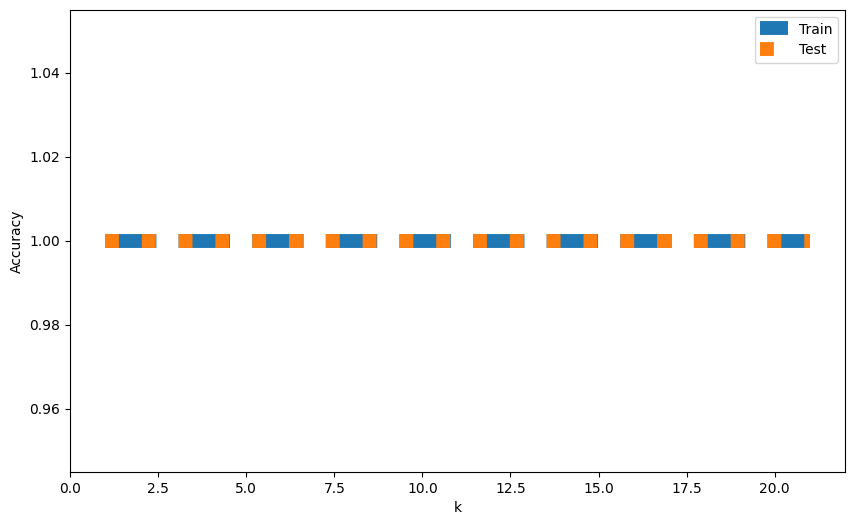

In [ ]:

k_values = [1,3,5,7,9,11,15,21]
train_acc = []
test_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)

    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_acc, label='Train',ls='--',lw=10)
plt.plot(k_values, test_acc, label='Test',ls=':',lw=10)

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


kNN (euclidean)
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


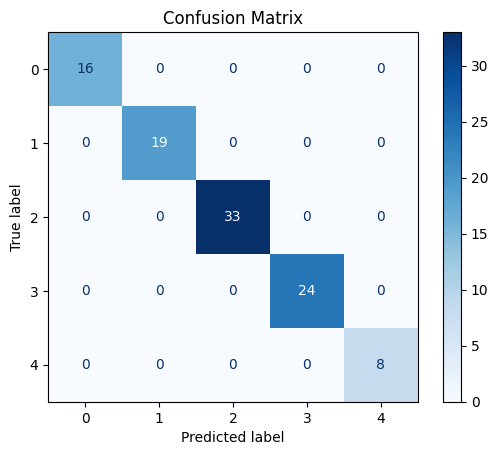


kNN (manhattan)
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


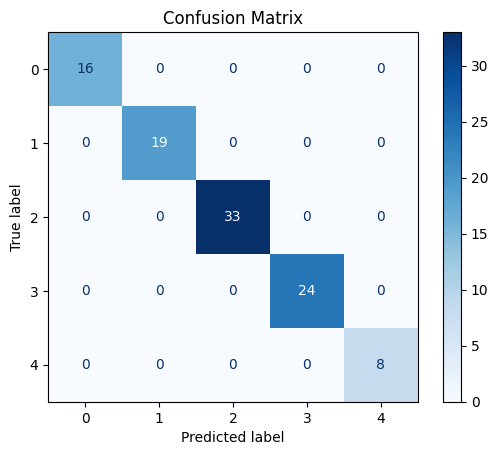

In [ ]:
for metric in ['euclidean', 'manhattan']:
    knn = KNeighborsClassifier(n_neighbors=7, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    evaluate_model(f"kNN ({metric})", y_test, y_pred)


Best kNN
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


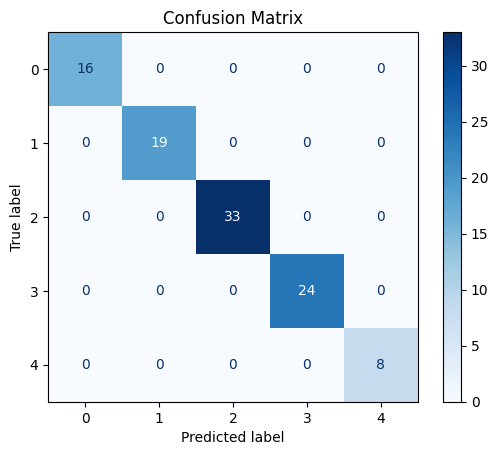

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
best_knn.fit(X_train, y_train)

y_pred_knn = best_knn.predict(X_test)
knn_metrics = evaluate_model("Best kNN", y_test, y_pred_knn)

**Discuss the computational implications of kNN at inference time in a hospital setting where a
new patient reading arrives every second. Is kNN practical here?**

Patient data is enormous and there are patients coming in every minute. This makes kNN impractical due to its long computation times finding distances with every other patient to form clusters

## Naive Bayes

In [ ]:
features_to_plot = ['HeartRate_mean', 'BP_Systolic_mean', 'SleepHours_mean']

for feature in features_to_plot:
    plt.figure()
    sns.histplot(data=X, x=feature, hue=y, kde=True)
    plt.title(feature)
    plt.show()


Naive Bayes
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


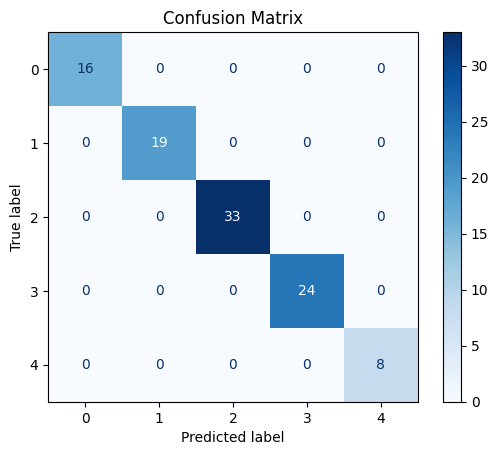

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
nb_metrics = evaluate_model("Naive Bayes", y_test, y_pred_nb)

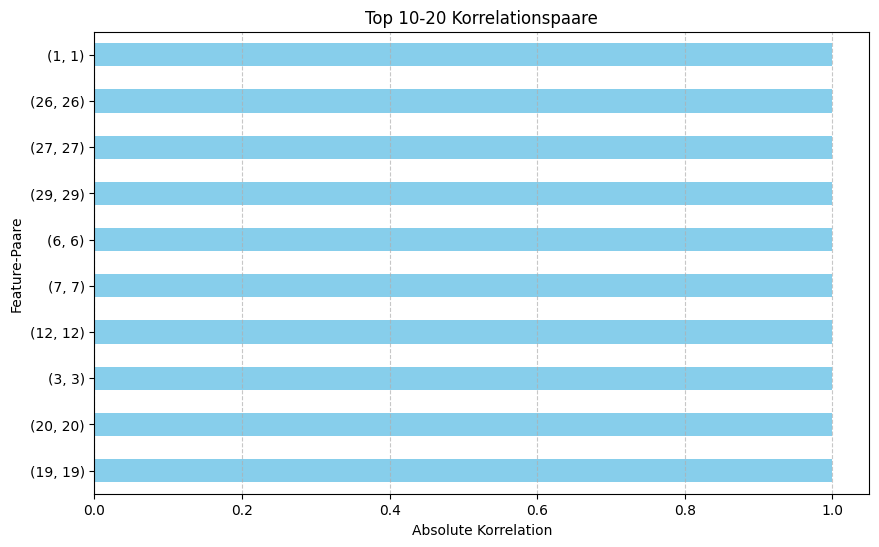

In [ ]:

corr = pd.DataFrame(X).corr()

# strongest correlations
top_pairs = corr_pairs[10:20]

# Plot erstellen
plt.figure(figsize=(10, 6))
top_pairs.plot(kind='barh', color='skyblue')

plt.gca().invert_yaxis()  # Höchste Werte nach oben
plt.xlabel('Absolute Korrelation')
plt.ylabel('Feature-Paare')
plt.title('Top 10-20 Correlations Pairs')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Compare Naïve Bayes performance to Decision Tree (C1) and kNN (C3). Under what
conditions would Naïve Bayes be preferred?**


Naive Bayes is preffered in settings where features are independent. In a clinical setting it isnt suitable as features are interlinked.

## SVM

In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
param_grid = {'C': [0.1, 1, 10, 100]}

# RBF
grid_rbf = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid_rbf.fit(X_train, y_train)

print("Best RBF C:", grid_rbf.best_params_)

# Polynomial
grid_poly = GridSearchCV(SVC(kernel='poly', degree=3), param_grid, cv=5)
grid_poly.fit(X_train, y_train)

print("Best Poly C:", grid_poly.best_params_)

Best RBF C: {'C': 0.1}
Best Poly C: {'C': 1}



SVM
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


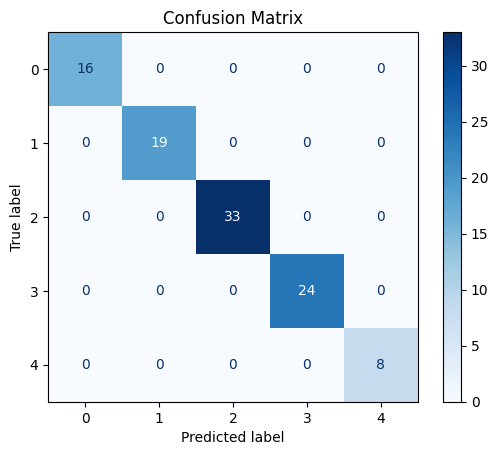

In [ ]:
svm = SVC(kernel='rbf', C=grid_rbf.best_params_['C'])
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
svm_metrics = evaluate_model("SVM", y_test, y_pred_svm)

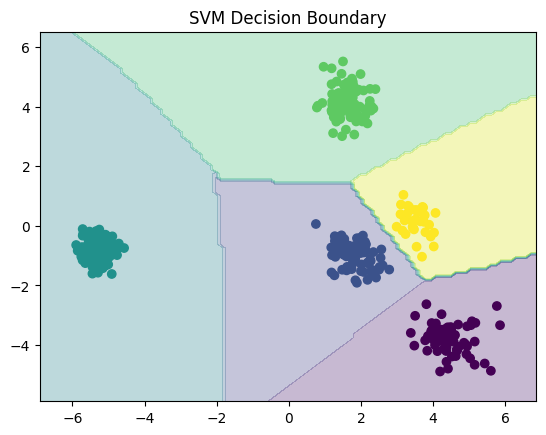

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

svm_2d = SVC(kernel='rbf', C=1)
svm_2d.fit(X_pca, y_train)

# plot
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train)
plt.title("SVM Decision Boundary")
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Rule-Based','KNN', 'Naive Bayes', 'SVM'],
    'Accuracy': [dt_metrics[0],rb_metrics[0], knn_metrics[0], nb_metrics[0], svm_metrics[0]],
    'Precision': [dt_metrics[1],rb_metrics[1], knn_metrics[1], nb_metrics[1], svm_metrics[1]],
    'Recall': [dt_metrics[2],rb_metrics[2], knn_metrics[2], nb_metrics[2], svm_metrics[2]],
    'F1': [dt_metrics[3],rb_metrics[3], knn_metrics[3], nb_metrics[3], svm_metrics[3]]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,1.0,1.0,1.0,1.0
1,Rule-Based,1.0,1.0,1.0,1.0
2,KNN,1.0,1.0,1.0,1.0
3,Naive Bayes,1.0,1.0,1.0,1.0
4,SVM,1.0,1.0,1.0,1.0


**SVM is a black-box model. Discuss the interpretability trade-off: would you choose SVM or
Decision Tree for deployment in a hospital where clinicians must understand the reasoning
behind each prediction?**


I would not chose SVM due to its lack of interpretability as doctors must understand the reasoning behind every prediction and SVM doesnt give that.

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame(X, columns=feature_cols)
df['Diagnosis'] = y_enc

corr_with_target = df.corr()['Diagnosis'].abs().sort_values(ascending=False)

print(corr_with_target.head(15))

Diagnosis                     1.000000
BodyTemperature_std           0.755713
HeartRate_std                 0.720092
HeartRate_min                 0.686275
RespiratoryRate_std           0.656017
BloodPressureDiastolic_min    0.620288
HeartRate_max                 0.607865
BodyTemperature_max           0.601661
StressLevel_min               0.546782
BloodPressureSystolic_min     0.543061
RespiratoryRate_max           0.504538
BodyTemperature_mean          0.495066
BloodPressureDiastolic_std    0.476906
RespiratoryRate_min           0.468667
BloodPressureSystolic_mean    0.418670
Name: Diagnosis, dtype: float64
